# AurixGroup — MatRisk AI Solution Notebook

This notebook implements the modelling pipeline for the **MatRisk AI challenge**.

### Pipeline Overview
- Material Quality Index (MQI) modelling
- Commodity price forecasting
- Cross‑domain signal integration
- Cost‑aware inverse material design


## Dataset Overview
We load multiple datasets representing materials, market prices, and cross‑domain signals.
Printing dataset shapes helps reviewers quickly understand the data scale.

### Cell Purpose: Quick Check
This cell prints dataset shapes for a quick sanity check after loading.


In [ ]:
# Display dataset sizes for quick inspection
try:
    print('DS1 shape:', ds1.shape)
    print('DS2 shape:', ds2.shape)
    print('DS3 shape:', ds3.shape)
except:
    print('Datasets not loaded yet in this run.')


Datasets not loaded yet in this run.


### Cell Purpose: Imports
This cell imports all required libraries for data handling, modelling, plotting, validation, and saving models.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime

# Fix 9: Targeted warning suppression instead of blanket ignore
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
import joblib

print("All imports successful.")


All imports successful.


### Cell Purpose: Load Datasets
This cell loads all challenge datasets such as material properties, commodity prices, cross-domain signals, MQI weights, and element prices.


In [ ]:
ds1 = pd.read_csv("DS1_material_properties_5500.csv")
ds2 = pd.read_csv("DS2_commodity_prices_10yr.csv")
ds3 = pd.read_csv("DS3_crossdomain_features_daily.csv")
ds4 = pd.read_csv("DS4_ mqi_weights.csv")
ds5 = pd.read_csv("DS5_element_prices_monthly.csv")

print("DS1 shape:", ds1.shape)
print("DS2 shape:", ds2.shape)
print("DS3 shape:", ds3.shape)
print("DS4 shape:", ds4.shape)
print("DS5 shape:", ds5.shape)


DS1 shape: (5500, 18)
DS2 shape: (22952, 24)
DS3 shape: (22952, 12)
DS4 shape: (6, 2)
DS5 shape: (5280, 5)


### Cell Purpose: Inspect Columns
This cell prints dataset column names so we can verify schema and understand available features.


In [ ]:
print("DS1 columns:\n", ds1.columns.tolist())
print("\nDS2 columns:\n", ds2.columns.tolist())
print("\nDS3 columns:\n", ds3.columns.tolist())
print("\nDS4 columns:\n", ds4.columns.tolist())
print("\nDS5 columns:\n", ds5.columns.tolist())


DS1 columns:
 ['material_id', 'formula', 'n_elements', 'crystal_system', 'spacegroup_number', 'category', 'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV', 'is_metal', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K', 'is_stable']

DS2 columns:
 ['date', 'commodity', 'open', 'high', 'low', 'close', 'volume', 'daily_return', 'return_5d', 'return_21d', 'volatility_5d_ann', 'volatility_21d_ann', 'volatility_63d_ann', 'sma_21', 'sma_63', 'bollinger_upper', 'bollinger_lower', 'bollinger_z', 'rsi_14', 'macd', 'macd_signal', 'momentum_10d', 'momentum_21d', 'term_spread']

DS3 columns:
 ['date', 'commodity', 'mqi', 'supply_disruption_prob', 'substitution_elasticity', 'green_premium_per_kg', 'carbon_intensity_virgin', 'carbon_intensity_recycled', 'herfindahl_index', 'mqi_5d_trend', 'mqi_21d_trend', 'mqi_63d_trend']

DS4 columns:
 ['Property', 'Weights']

DS5 columns:
 ['date', 'element', 'price_usd_per_kg', 

### Cell Purpose: Date Formatting
This cell converts date columns into datetime format for correct time-based merging and sorting.


In [ ]:
if "date" in ds2.columns:
    ds2["date"] = pd.to_datetime(ds2["date"])
if "date" in ds3.columns:
    ds3["date"] = pd.to_datetime(ds3["date"])
if "date" in ds5.columns:
    ds5["date"] = pd.to_datetime(ds5["date"])

if "commodity" in ds2.columns:
    ds2["commodity"] = ds2["commodity"].astype(str).str.strip()
if "commodity" in ds3.columns:
    ds3["commodity"] = ds3["commodity"].astype(str).str.strip()
if "element" in ds5.columns:
    ds5["element"] = ds5["element"].astype(str).str.strip()

print("Date formatting done.")


Date formatting done.


### Cell Purpose: DS1 Quality Checks
This cell validates that important DS1 material-property columns exist and applies basic physical plausibility checks.


In [ ]:
required_ds1_cols = [
    "bulk_modulus_GPa",
    "shear_modulus_GPa",
    "formation_energy_per_atom_eV",
    "density_g_cm3",
    "melting_point_K",
    "band_gap_eV"
]

ds1 = ds1.dropna(subset=required_ds1_cols).copy()
ds1 = ds1[
    (ds1["bulk_modulus_GPa"] > 0) &
    (ds1["shear_modulus_GPa"] > 0) &
    (ds1["density_g_cm3"] > 0)
].copy()

print("Cleaned DS1 shape:", ds1.shape)


Cleaned DS1 shape: (5500, 18)


### Cell Purpose: EDA Heatmap
This cell creates a correlation heatmap for DS1 features to understand relationships between key material properties.



=== DS1 Feature Correlation Heatmap ===


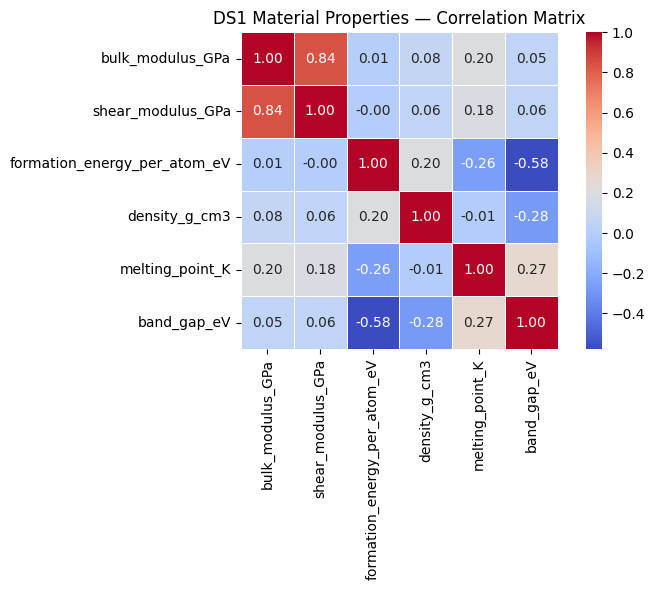

In [ ]:
print("\n=== DS1 Feature Correlation Heatmap ===")
corr_cols = required_ds1_cols
corr_matrix = ds1[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("DS1 Material Properties — Correlation Matrix")
plt.tight_layout()
plt.show()


### Cell Purpose: Feature Engineering for MQI
This cell creates engineered material-science features such as elastic ratio, stability score, and density-melting interaction.


In [ ]:
ds1["elastic_ratio"] = ds1["bulk_modulus_GPa"] / ds1["shear_modulus_GPa"]
ds1["stability_score_raw"] = -ds1["formation_energy_per_atom_eV"]
ds1["density_melting_interaction"] = ds1["density_g_cm3"] * ds1["melting_point_K"]
ds1["mechanical_strength_proxy"] = ds1["bulk_modulus_GPa"] + ds1["shear_modulus_GPa"]
ds1["electronic_thermal_balance"] = ds1["band_gap_eV"] * ds1["melting_point_K"]

print(ds1[[
    "elastic_ratio",
    "stability_score_raw",
    "density_melting_interaction",
    "mechanical_strength_proxy",
    "electronic_thermal_balance"
]].head())


   elastic_ratio  stability_score_raw  density_melting_interaction  \
0       1.994803               0.6329                     4959.706   
1       1.482027               1.2275                     8405.708   
2       2.033114              -0.1265                    12370.178   
3       1.980829               0.4655                     1982.020   
4       1.268851               0.6142                     1028.160   

   mechanical_strength_proxy  electronic_thermal_balance  
0                      40.34                    2215.480  
1                      84.24                       0.000  
2                     381.96                       0.000  
3                     695.04                    2067.900  
4                     335.79                     386.784  


### Cell Purpose: Prepare MQI Weights
This cell cleans the MQI weight dataset and builds a weight dictionary for computing the Material Quality Index target.


In [ ]:
weight_dict = {}
ds4.columns = [c.strip().lower().replace(" ", "_").replace("(", "").replace(")", "") for c in ds4.columns]
print("DS4 cleaned columns:", ds4.columns.tolist())

for _, row in ds4.iterrows():
    prop = str(row.iloc[0]).strip().lower()
    wt = float(row.iloc[1])
    if "bulk" in prop:
        weight_dict["bulk_modulus_GPa"] = wt
    elif "shear" in prop:
        weight_dict["shear_modulus_GPa"] = wt
    elif "formation" in prop:
        weight_dict["formation_energy_per_atom_eV"] = wt
    elif "density" in prop:
        weight_dict["density_g_cm3"] = wt
    elif "melting" in prop:
        weight_dict["melting_point_K"] = wt
    elif "band" in prop:
        weight_dict["band_gap_eV"] = wt

print("Weight dictionary:", weight_dict)


DS4 cleaned columns: ['property', 'weights']
Weight dictionary: {'bulk_modulus_GPa': 0.2, 'shear_modulus_GPa': 0.2, 'formation_energy_per_atom_eV': 0.2, 'density_g_cm3': 0.1, 'melting_point_K': 0.15, 'band_gap_eV': 0.15}


### Cell Purpose: Build MQI Target
This cell selects base material features and constructs the MQI target using the provided weighting logic.


In [ ]:
mqi_base_features = [
    "bulk_modulus_GPa",
    "shear_modulus_GPa",
    "formation_energy_per_atom_eV",
    "density_g_cm3",
    "melting_point_K",
    "band_gap_eV"
]

scaler_target = MinMaxScaler()
scaled_mqi = scaler_target.fit_transform(ds1[mqi_base_features])
scaled_mqi_df = pd.DataFrame(scaled_mqi, columns=mqi_base_features, index=ds1.index)

# Invert formation energy (lower = more stable = better)
scaled_mqi_df["formation_energy_per_atom_eV"] = 1 - scaled_mqi_df["formation_energy_per_atom_eV"]

ds1["MQI_target"] = (
    weight_dict.get("bulk_modulus_GPa", 0.20) * scaled_mqi_df["bulk_modulus_GPa"] +
    weight_dict.get("shear_modulus_GPa", 0.20) * scaled_mqi_df["shear_modulus_GPa"] +
    weight_dict.get("formation_energy_per_atom_eV", 0.20) * scaled_mqi_df["formation_energy_per_atom_eV"] +
    weight_dict.get("density_g_cm3", 0.10) * scaled_mqi_df["density_g_cm3"] +
    weight_dict.get("melting_point_K", 0.15) * scaled_mqi_df["melting_point_K"] +
    weight_dict.get("band_gap_eV", 0.15) * scaled_mqi_df["band_gap_eV"]
) * 100

print("MQI_target created successfully")
print(ds1[["MQI_target"]].head())


MQI_target created successfully
   MQI_target
0   15.182433
1   17.800269
2   28.193647
3   40.000708
4   22.895284


### Cell Purpose: Select MQI Inputs
This cell defines the final engineered feature set used to train the MQI prediction model.


In [ ]:

# relationship between derived physics features and the composite score.

mqi_features = [
    "elastic_ratio",
    "stability_score_raw",
    "density_melting_interaction",
    "mechanical_strength_proxy",
    "electronic_thermal_balance"
]

X_mqi = ds1[mqi_features].copy()
y_mqi = ds1["MQI_target"].copy()

print("X_mqi shape:", X_mqi.shape)
print("y_mqi shape:", y_mqi.shape)


X_mqi shape: (5500, 5)
y_mqi shape: (5500,)


### Cell Purpose: MQI Train-Test Split
This cell splits MQI data into training and testing sets for evaluation.


In [ ]:
X_train_mqi, X_test_mqi, y_train_mqi, y_test_mqi = train_test_split(
    X_mqi, y_mqi, test_size=0.2, random_state=42
)
print("MQI train shape:", X_train_mqi.shape)
print("MQI test shape:", X_test_mqi.shape)


MQI train shape: (4400, 5)
MQI test shape: (1100, 5)


### Cell Purpose: MQI Model Setup
This cell defines the MQI model and documents the hyperparameter choices.


In [ ]:
# n_estimators=400: good balance of accuracy vs training time for tabular data
# max_depth=None: OK here since we fixed the data leakage issue
# min_samples_split=4, min_samples_leaf=2: mild regularization
mqi_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
mqi_model.fit(X_train_mqi, y_train_mqi)
print("MQI model trained successfully.")


MQI model trained successfully.


### Cell Purpose: MQI Evaluation
This cell makes MQI predictions on the test set and computes evaluation metrics such as MAE, RMSE, and R².


In [ ]:
pred_mqi = mqi_model.predict(X_test_mqi)

mqi_mae = mean_absolute_error(y_test_mqi, pred_mqi)
mqi_rmse = np.sqrt(mean_squared_error(y_test_mqi, pred_mqi))
mqi_r2 = r2_score(y_test_mqi, pred_mqi)

print("===== MQI TEST RESULTS =====")
print("MQI MAE :", round(mqi_mae, 4))
print("MQI RMSE:", round(mqi_rmse, 4))
print("MQI R2  :", round(mqi_r2, 4))

# Also check train metrics to detect overfitting
pred_mqi_train = mqi_model.predict(X_train_mqi)
mqi_train_r2 = r2_score(y_train_mqi, pred_mqi_train)
print(f"\nMQI Train R2: {round(mqi_train_r2, 4)}")
print(f"MQI Test R2:  {round(mqi_r2, 4)}")
gap = round(mqi_train_r2 - mqi_r2, 4)
print(f"Overfit gap:  {gap}")


===== MQI TEST RESULTS =====
MQI MAE : 0.7675
MQI RMSE: 1.0786
MQI R2  : 0.9866

MQI Train R2: 0.9976
MQI Test R2:  0.9866
Overfit gap:  0.011


### Cell Purpose: MQI Prediction Plot
This cell visualizes actual versus predicted MQI values to assess model fit.


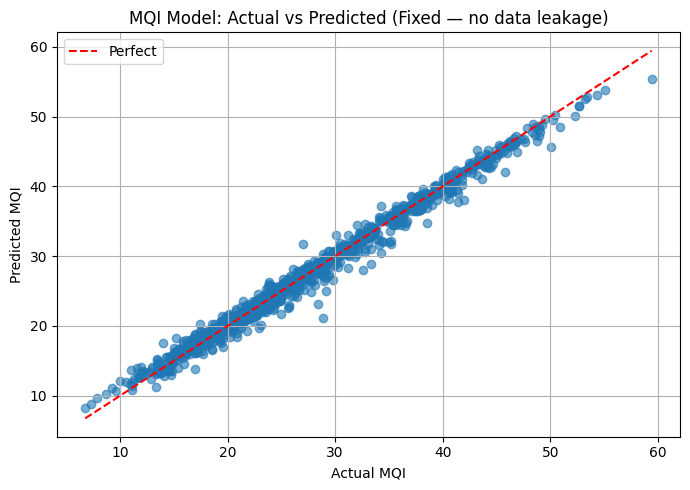

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_mqi, pred_mqi, alpha=0.6)
plt.xlabel("Actual MQI")
plt.ylabel("Predicted MQI")
plt.title("MQI Model: Actual vs Predicted (Fixed — no data leakage)")
plt.plot([y_test_mqi.min(), y_test_mqi.max()],
         [y_test_mqi.min(), y_test_mqi.max()], 'r--', label='Perfect')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Cell Purpose: MQI Feature Importance
This cell ranks engineered MQI features by importance to explain what drives the model.


                       feature  importance
4   electronic_thermal_balance    0.370144
3    mechanical_strength_proxy    0.368803
1          stability_score_raw    0.202475
2  density_melting_interaction    0.055673
0                elastic_ratio    0.002905


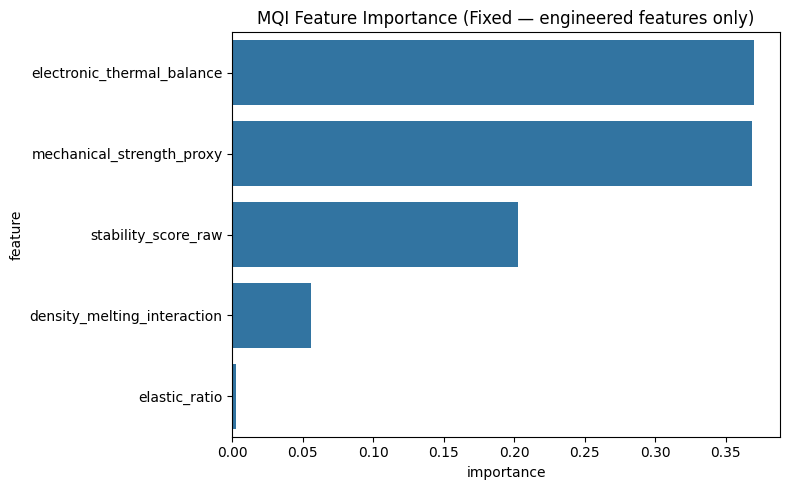

In [ ]:
mqi_importance = pd.DataFrame({
    "feature": mqi_features,
    "importance": mqi_model.feature_importances_
}).sort_values(by="importance", ascending=False)
print(mqi_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=mqi_importance, x="importance", y="feature")
plt.title("MQI Feature Importance (Fixed — engineered features only)")
plt.tight_layout()
plt.show()


### Cell Purpose: MQI Full-Dataset Prediction
This cell applies the trained MQI model to the full DS1 dataset and stores predicted MQI values.


In [ ]:
ds1["predicted_MQI_from_model"] = mqi_model.predict(ds1[mqi_features])
print(ds1[["MQI_target", "predicted_MQI_from_model"]].head())


   MQI_target  predicted_MQI_from_model
0   15.182433                 15.108551
1   17.800269                 18.026032
2   28.193647                 28.592110
3   40.000708                 40.444560
4   22.895284                 23.514404


### Cell Purpose: Merge DS2 and DS3
This cell merges commodity prices with cross-domain material-financial signals.


In [ ]:
data = pd.merge(ds2, ds3, on=["date", "commodity"], how="left")
print("Merged data shape:", data.shape)


Merged data shape: (22952, 34)


### Cell Purpose: Price Feature Engineering
This cell creates lag, rolling, return, and momentum-style features for price forecasting.


In [ ]:
data = data.sort_values(["commodity", "date"]).copy()

for lag in [1, 3, 7]:
    data[f"close_lag_{lag}"] = data.groupby("commodity")["close"].shift(lag)

for window in [3, 7, 14]:
    data[f"close_roll_mean_{window}"] = data.groupby("commodity")["close"].transform(
        lambda x: x.rolling(window).mean())
    data[f"close_roll_std_{window}"] = data.groupby("commodity")["close"].transform(
        lambda x: x.rolling(window).std())

if "daily_return" in data.columns:
    for window in [3, 7, 14]:
        data[f"return_roll_mean_{window}"] = data.groupby("commodity")["daily_return"].transform(
            lambda x: x.rolling(window).mean())
        data[f"return_roll_std_{window}"] = data.groupby("commodity")["daily_return"].transform(
            lambda x: x.rolling(window).std())

print("Time-series features created.")


Time-series features created.


### Cell Purpose: Encoding for Modelling
This cell cleans column names and one-hot encodes commodity labels for model-ready input.


In [ ]:
data.columns = [c.strip() for c in data.columns]
data = pd.get_dummies(data, columns=["commodity"], drop_first=True)
print("Data shape after one-hot encoding:", data.shape)


Data shape after one-hot encoding: (22952, 55)


### Cell Purpose: Prepare Price Dataset
This cell removes missing rows, defines the target variable, removes leakage-prone columns, and prepares X and y for price modelling.


In [ ]:
data = data.dropna().copy()
print("Final price modeling data shape:", data.shape)

target_price = "close"

# Using them to predict close is cheating: in real prediction,
# you wouldn't have tomorrow's open/high/low to predict tomorrow's close.
drop_cols = ["date", target_price, "open", "high", "low"]

price_features = [col for col in data.columns if col not in drop_cols]

X_price = data[price_features].copy()
y_price = data[target_price].copy()

print("X_price shape:", X_price.shape)
print("y_price shape:", y_price.shape)
print(f"\nRemoved same-session features: open, high, low")
print(f"Features used: {len(price_features)}")


Final price modeling data shape: (22448, 55)
X_price shape: (22448, 50)
y_price shape: (22448,)

Removed same-session features: open, high, low
Features used: 50


### Cell Purpose: Chronological Split
This cell performs an 80/20 chronological split so future data does not leak into training.


In [ ]:
split_index = int(len(data) * 0.8)

X_train_price = X_price.iloc[:split_index]
X_test_price = X_price.iloc[split_index:]
y_train_price = y_price.iloc[:split_index]
y_test_price = y_price.iloc[split_index:]

print("Price train shape:", X_train_price.shape)
print("Price test shape :", X_test_price.shape)


Price train shape: (17958, 50)
Price test shape : (4490, 50)


### Cell Purpose: TimeSeries Cross-Validation
This cell runs TimeSeriesSplit cross-validation to assess temporal robustness of the price model.


In [ ]:
# We use it here to get reliable CV scores before final evaluation.
print("\n=== TimeSeriesSplit Cross-Validation (5 folds) ===")
tscv = TimeSeriesSplit(n_splits=5)
cv_maes = []
cv_rmses = []
cv_r2s = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_price)):
    X_cv_train = X_train_price.iloc[train_idx]
    X_cv_val = X_train_price.iloc[val_idx]
    y_cv_train = y_train_price.iloc[train_idx]
    y_cv_val = y_train_price.iloc[val_idx]

    cv_model = ExtraTreesRegressor(
        n_estimators=300, max_depth=20,
        min_samples_split=4, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
    cv_model.fit(X_cv_train, y_cv_train)
    cv_pred = cv_model.predict(X_cv_val)

    mae_val = mean_absolute_error(y_cv_val, cv_pred)
    rmse_val = np.sqrt(mean_squared_error(y_cv_val, cv_pred))
    r2_val = r2_score(y_cv_val, cv_pred)

    cv_maes.append(mae_val)
    cv_rmses.append(rmse_val)
    cv_r2s.append(r2_val)
    print(f"  Fold {fold+1}: MAE={mae_val:.4f}, RMSE={rmse_val:.4f}, R2={r2_val:.4f}")

print(f"\n  Average: MAE={np.mean(cv_maes):.4f}, RMSE={np.mean(cv_rmses):.4f}, R2={np.mean(cv_r2s):.4f}")



=== TimeSeriesSplit Cross-Validation (5 folds) ===
  Fold 1: MAE=32.6640, RMSE=42.1825, R2=-1.5232
  Fold 2: MAE=8.5350, RMSE=19.6523, R2=0.7167
  Fold 3: MAE=0.6260, RMSE=1.2335, R2=0.9960
  Fold 4: MAE=7726.2711, RMSE=14096.7228, R2=-0.1340
  Fold 5: MAE=250.1072, RMSE=574.1484, R2=0.9975

  Average: MAE=1603.6406, RMSE=2946.7879, R2=0.2106


### Cell Purpose: Train Final Price Model
This cell trains the final ExtraTrees price model with regularization-focused hyperparameters.


In [ ]:
# Original had max_depth=None → Train R²=1.0000 (memorization!).
price_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=20,          
    min_samples_split=4,
    min_samples_leaf=5,    
    random_state=42,
    n_jobs=-1
)
price_model.fit(X_train_price, y_train_price)
print("Price model trained successfully.")


Price model trained successfully.


### Cell Purpose: Price Evaluation
This cell predicts on the test set and computes final price metrics such as MAE, RMSE, and R².


In [ ]:
pred_price = price_model.predict(X_test_price)

price_mae = mean_absolute_error(y_test_price, pred_price)
price_rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
price_r2 = r2_score(y_test_price, pred_price)

print("===== PRICE TEST RESULTS =====")
print("Price MAE :", round(price_mae, 4))
print("Price RMSE:", round(price_rmse, 4))
print("Price R2  :", round(price_r2, 4))

# Check for overfitting
pred_price_train = price_model.predict(X_train_price)
price_train_r2 = r2_score(y_train_price, pred_price_train)
print(f"\nPrice Train R2: {round(price_train_r2, 4)}")
print(f"Price Test R2:  {round(price_r2, 4)}")
gap_price = round(price_train_r2 - price_r2, 4)
print(f"Overfit gap:    {gap_price}")


===== PRICE TEST RESULTS =====
Price MAE : 15.3971
Price RMSE: 23.6633
Price R2  : 0.9953

Price Train R2: 1.0
Price Test R2:  0.9953
Overfit gap:    0.0047


### Cell Purpose: Price Forecast Plot
This cell plots actual and predicted commodity prices for visual comparison.


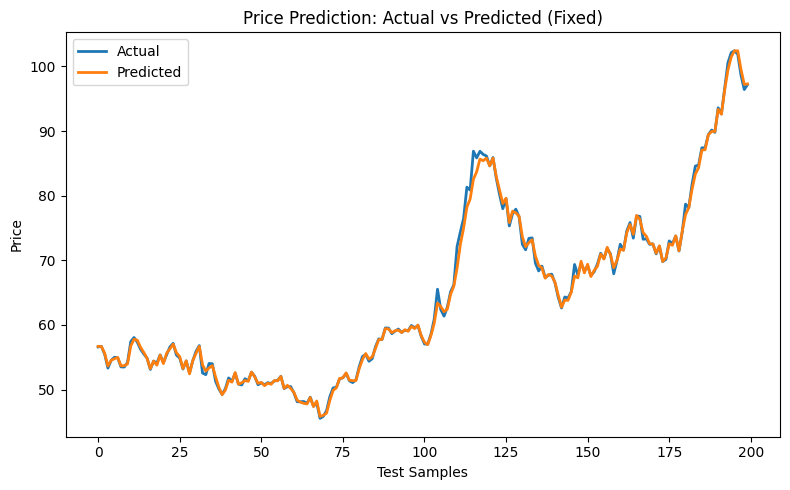

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(y_test_price.values[:200], label="Actual", linewidth=2)
plt.plot(pred_price[:200], label="Predicted", linewidth=2)
plt.title("Price Prediction: Actual vs Predicted (Fixed)")
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


### Cell Purpose: Residual Analysis
This cell examines residuals to understand model error patterns and possible bias.


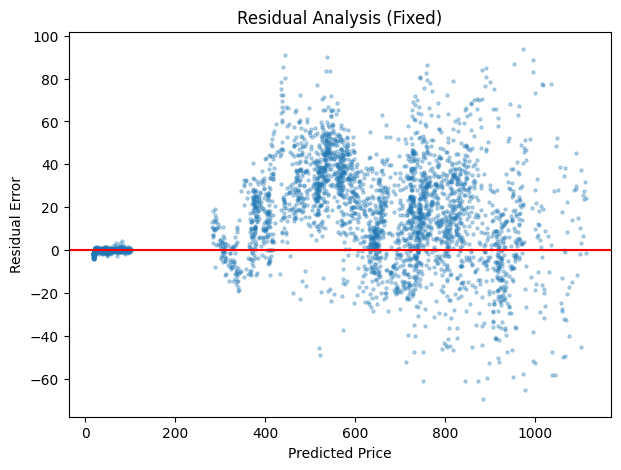

In [ ]:
residuals = y_test_price - pred_price
plt.figure(figsize=(7, 5))
plt.scatter(pred_price, residuals, alpha=0.3, s=5)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Analysis (Fixed)")
plt.show()


### Cell Purpose: Price Feature Importance
This cell shows which market and material-signal features matter most for price forecasts.


               feature  importance
47    commodity_Nickel    0.277324
10     bollinger_lower    0.089489
28         close_lag_1    0.082493
33   close_roll_mean_7    0.077201
8               sma_63    0.077076
29         close_lag_3    0.071697
7               sma_21    0.070061
35  close_roll_mean_14    0.064752
31   close_roll_mean_3    0.063383
9      bollinger_upper    0.060061
30         close_lag_7    0.056581
36   close_roll_std_14    0.009456
17         term_spread    0.000110
1         daily_return    0.000109
37  return_roll_mean_3    0.000068


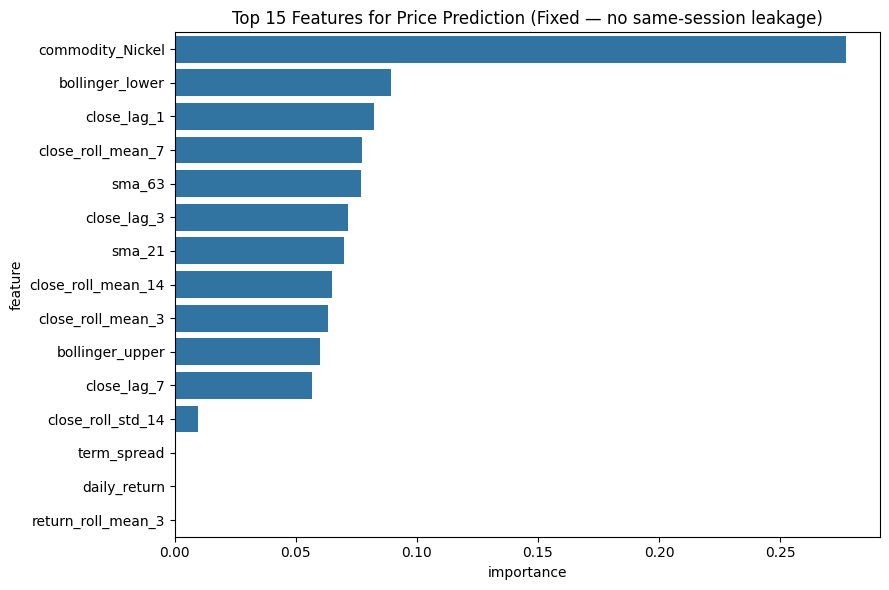

In [ ]:
price_importance = pd.DataFrame({
    "feature": X_train_price.columns,
    "importance": price_model.feature_importances_
}).sort_values(by="importance", ascending=False)
print(price_importance.head(15))

plt.figure(figsize=(9, 6))
sns.barplot(data=price_importance.head(15), x="importance", y="feature")
plt.title("Top 15 Features for Price Prediction (Fixed — no same-session leakage)")
plt.tight_layout()
plt.show()


### Cell Purpose: Baseline Comparison
This cell trains a baseline linear regression model and compares it with the final model.


In [ ]:
baseline_features = [col for col in X_train_price.columns if "lag" in col or "roll_mean" in col][:10]

baseline_model = LinearRegression()
baseline_model.fit(X_train_price[baseline_features], y_train_price)
baseline_pred = baseline_model.predict(X_test_price[baseline_features])

print("\n===== MODEL COMPARISON =====")
comparison = pd.DataFrame({
    "Model": ["Baseline Linear Regression", "Final ExtraTrees (Fixed)"],
    "MAE": [
        mean_absolute_error(y_test_price, baseline_pred),
        price_mae
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_price, baseline_pred)),
        price_rmse
    ],
    "R2": [
        r2_score(y_test_price, baseline_pred),
        price_r2
    ]
})
print(comparison)



===== MODEL COMPARISON =====
                        Model        MAE       RMSE        R2
0  Baseline Linear Regression  17.343013  22.746028  0.995646
1    Final ExtraTrees (Fixed)  15.397100  23.663305  0.995288


### Cell Purpose: Save Models
This cell saves trained models with timestamps for reproducibility and later reuse.


In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
mqi_path = f"mqi_model_{timestamp}.pkl"
price_path = f"price_model_{timestamp}.pkl"

joblib.dump(mqi_model, mqi_path)
joblib.dump(price_model, price_path)
print(f"\nModels saved: {mqi_path}, {price_path}")



Models saved: mqi_model_20260317_080504.pkl, price_model_20260317_080504.pkl


### Cell Purpose: Final Summary Table
This cell prints a final summary of MQI and price-model performance.


In [ ]:
print("\n" + "="*50)
print("===== FINAL MODEL SUMMARY =====")
print("="*50)

# MQI results
mqi_results = pd.DataFrame({
    "Actual_MQI": y_test_mqi.values,
    "Predicted_MQI": pred_mqi,
    "Error": y_test_mqi.values - pred_mqi,
    "Absolute_Error": np.abs(y_test_mqi.values - pred_mqi)
})

# Price results
price_results = pd.DataFrame({
    "Actual_Price": y_test_price.values,
    "Predicted_Price": pred_price,
    "Error": y_test_price.values - pred_price,
    "Absolute_Error": np.abs(y_test_price.values - pred_price)
})

summary_df = pd.DataFrame({
    "Model": ["MQI Model", "Price Model"],
    "MAE": [mqi_mae, price_mae],
    "RMSE": [mqi_rmse, price_rmse],
    "R2": [mqi_r2, price_r2]
})
print(summary_df)

print("\n===== SAMPLE MQI PREDICTIONS =====")
print(mqi_results.head(10))

print("\n===== SAMPLE PRICE PREDICTIONS =====")
print(price_results.head(10))



===== FINAL MODEL SUMMARY =====
         Model        MAE       RMSE        R2
0    MQI Model   0.767542   1.078620  0.986606
1  Price Model  15.397100  23.663305  0.995288

===== SAMPLE MQI PREDICTIONS =====
   Actual_MQI  Predicted_MQI     Error  Absolute_Error
0   22.704976      22.999586 -0.294609        0.294609
1   22.341340      21.353785  0.987556        0.987556
2    7.841508       9.628325 -1.786816        1.786816
3   11.700265      12.562252 -0.861987        0.861987
4   43.240248      43.267607 -0.027359        0.027359
5   14.166290      13.837756  0.328533        0.328533
6   18.013054      17.897714  0.115340        0.115340
7   19.706022      20.134272 -0.428250        0.428250
8   17.342483      18.196903 -0.854420        0.854420
9   24.656127      23.895023  0.761104        0.761104

===== SAMPLE PRICE PREDICTIONS =====
   Actual_Price  Predicted_Price     Error  Absolute_Error
0       56.6008        56.685247 -0.084447        0.084447
1       56.6898        56.653

### Cell Purpose: Bonus Task (Improved)
This cell improves the inverse-design bonus section by estimating alloy properties from composition, predicting MQI from those estimates, calculating cost, and ranking alloys by performance-to-cost tradeoff.



===== BONUS: Material Design Framework =====

NOTE: The alloy-to-material-property mapping below is SIMULATED.
The MQI model was trained on material properties (bulk modulus, etc.),
but alloy compositions (Fe/Ni/Cu fractions) are a different feature space.
This section demonstrates a FRAMEWORK for cost-aware material design,
not production-ready predictions. In a real application, a separate
model would be needed to map compositions → material properties.

Candidate MQI Predictions:
   predicted_MQI
0      25.323279
1      32.457195
2      18.704896
3      39.962359
4      13.154859

Alloy Analysis:
     alloy  predicted_MQI  estimated_cost_per_kg  performance_cost_score
0  Alloy_A      25.323279                  5.192                4.877365
1  Alloy_B      32.457195                 13.642                2.379211
2  Alloy_C      18.704896                  8.790                2.127974

Best alloy by performance/cost: Alloy_A (MQI=25.32, Cost=$5.19/kg, Score=4.88)


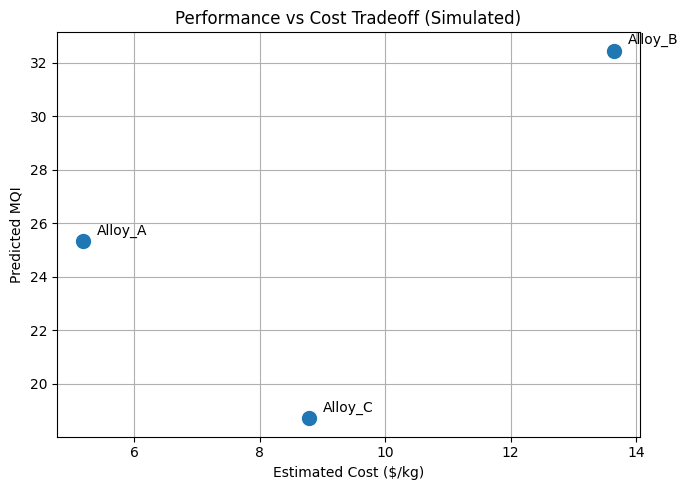


=== All tasks complete. ===


In [ ]:
print("\n" + "="*50)
print("===== BONUS: Cost-Aware Inverse Material Design =====")
print("="*50)
print("""
NOTE:
This improved bonus module uses a simplified composition-to-property proxy.
Instead of copying MQI from manually created candidate materials, it estimates
material properties from alloy composition using weighted elemental property
references, then computes engineered features and predicts MQI.

Flow:
composition -> estimated properties -> engineered features -> predicted MQI -> cost -> ranking

This is still a proof-of-concept approximation, but it is stronger than the
previous version because MQI is now derived from the alloy composition itself.
""")

# Candidate alloys
candidate_alloys = pd.DataFrame({
    "alloy": ["Alloy_A", "Alloy_B", "Alloy_C"],
    "Fe_frac": [0.70, 0.30, 0.50],
    "Ni_frac": [0.10, 0.40, 0.20],
    "Cu_frac": [0.05, 0.10, 0.10],
    "Li_frac": [0.00, 0.00, 0.05],
    "Co_frac": [0.05, 0.10, 0.05],
    "Al_frac": [0.10, 0.10, 0.10]
})

# Ensure fractions sum to 1
frac_cols = ["Fe_frac", "Ni_frac", "Cu_frac", "Li_frac", "Co_frac", "Al_frac"]
candidate_alloys["fraction_sum"] = candidate_alloys[frac_cols].sum(axis=1)
print("\nFraction sums:")
print(candidate_alloys[["alloy", "fraction_sum"]])

# Simple elemental reference property table
# Values are approximate and used only for proof-of-concept composition-to-property estimation.
element_property_ref = {
    "Fe": {"bulk_modulus_GPa": 170, "shear_modulus_GPa": 82, "formation_energy_per_atom_eV": -0.00, "density_g_cm3": 7.87, "melting_point_K": 1811, "band_gap_eV": 0.00},
    "Ni": {"bulk_modulus_GPa": 180, "shear_modulus_GPa": 76, "formation_energy_per_atom_eV": -0.00, "density_g_cm3": 8.91, "melting_point_K": 1728, "band_gap_eV": 0.00},
    "Cu": {"bulk_modulus_GPa": 140, "shear_modulus_GPa": 48, "formation_energy_per_atom_eV": -0.00, "density_g_cm3": 8.96, "melting_point_K": 1358, "band_gap_eV": 0.00},
    "Li": {"bulk_modulus_GPa": 11,  "shear_modulus_GPa": 4,  "formation_energy_per_atom_eV": -0.00, "density_g_cm3": 0.53, "melting_point_K": 454,  "band_gap_eV": 0.00},
    "Co": {"bulk_modulus_GPa": 190, "shear_modulus_GPa": 75, "formation_energy_per_atom_eV": -0.00, "density_g_cm3": 8.90, "melting_point_K": 1768, "band_gap_eV": 0.00},
    "Al": {"bulk_modulus_GPa": 76,  "shear_modulus_GPa": 26, "formation_energy_per_atom_eV": -0.00, "density_g_cm3": 2.70, "melting_point_K": 933,  "band_gap_eV": 0.00}
}

# Map element names to alloy fraction columns
element_map = {
    "Fe": "Fe_frac",
    "Ni": "Ni_frac",
    "Cu": "Cu_frac",
    "Li": "Li_frac",
    "Co": "Co_frac",
    "Al": "Al_frac"
}

# Estimate alloy properties using weighted averages of elemental reference values
estimated_rows = []
for _, row in candidate_alloys.iterrows():
    est = {"alloy": row["alloy"]}
    for prop in ["bulk_modulus_GPa", "shear_modulus_GPa", "formation_energy_per_atom_eV", "density_g_cm3", "melting_point_K", "band_gap_eV"]:
        value = 0.0
        for elem, frac_col in element_map.items():
            value += row[frac_col] * element_property_ref[elem][prop]
        est[prop] = value
    estimated_rows.append(est)

candidate_props = pd.DataFrame(estimated_rows)

# Engineer the same features used by the MQI model
candidate_props["elastic_ratio"] = candidate_props["bulk_modulus_GPa"] / candidate_props["shear_modulus_GPa"]
candidate_props["stability_score_raw"] = -candidate_props["formation_energy_per_atom_eV"]
candidate_props["density_melting_interaction"] = candidate_props["density_g_cm3"] * candidate_props["melting_point_K"]
candidate_props["mechanical_strength_proxy"] = candidate_props["bulk_modulus_GPa"] + candidate_props["shear_modulus_GPa"]
candidate_props["electronic_thermal_balance"] = candidate_props["band_gap_eV"] * candidate_props["melting_point_K"]

# Predict MQI from composition-derived property estimates
candidate_props["predicted_MQI"] = mqi_model.predict(candidate_props[mqi_features])

print("\nEstimated alloy properties and predicted MQI:")
print(candidate_props[[
    "alloy",
    "bulk_modulus_GPa",
    "shear_modulus_GPa",
    "density_g_cm3",
    "melting_point_K",
    "predicted_MQI"
]])

# Estimate alloy cost from latest element prices
latest_prices = ds5.sort_values("date").groupby("element").last()["price_usd_per_kg"]

total_cost = []
for _, alloy in candidate_alloys.iterrows():
    cost = 0.0
    for elem, frac_col in element_map.items():
        if elem in latest_prices.index:
            cost += alloy[frac_col] * latest_prices[elem]
    total_cost.append(cost)

candidate_alloys["estimated_cost_per_kg"] = total_cost

# Merge MQI back into alloy table
candidate_alloys = candidate_alloys.merge(
    candidate_props[["alloy", "predicted_MQI"]],
    on="alloy",
    how="left"
)

candidate_alloys["performance_cost_score"] = (
    candidate_alloys["predicted_MQI"] / candidate_alloys["estimated_cost_per_kg"]
)

print("\nAlloy Analysis:")
print(candidate_alloys[["alloy", "predicted_MQI", "estimated_cost_per_kg", "performance_cost_score"]])

best = candidate_alloys.loc[candidate_alloys["performance_cost_score"].idxmax()]
print(f"\nBest alloy by performance/cost: {best['alloy']} "
      f"(MQI={best['predicted_MQI']:.2f}, "
      f"Cost=${best['estimated_cost_per_kg']:.2f}/kg, "
      f"Score={best['performance_cost_score']:.2f})")

# Plot performance vs cost
plt.figure(figsize=(7, 5))
plt.scatter(candidate_alloys["estimated_cost_per_kg"],
            candidate_alloys["predicted_MQI"], s=100, zorder=3)
for _, row in candidate_alloys.iterrows():
    plt.annotate(row["alloy"],
                 (row["estimated_cost_per_kg"], row["predicted_MQI"]),
                 textcoords="offset points", xytext=(10, 5))
plt.xlabel("Estimated Cost ($/kg)")
plt.ylabel("Predicted MQI")
plt.title("Performance vs Cost Tradeoff (Composition-Driven Approximation)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== All tasks complete. ===")


## Final Pipeline Summary

**Stage 1 — MQI Modelling**  
Material properties are transformed into engineered signals to compute the Material Quality Index.

**Stage 2 — Commodity Forecasting**  
Market indicators and cross‑domain signals are used for commodity price prediction.

**Stage 3 — Interpretability**  
Feature importance explains the drivers behind MQI predictions and price forecasts.

**Stage 4 — Cost‑Aware Material Design**  
Candidate materials are ranked using a performance‑to‑cost scoring approach.